In [95]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [96]:
class CriketState(TypedDict):
    runs: int
    balls: int 
    run_rate: float

    required_rr: float 
    score_status: str

In [97]:
def count_run_rate(state: CriketState):
    if state['balls'] == 0:
        return {"run_rate": 0.0}
    return {"run_rate": state['runs'] / state['balls'] * 6}

def positive_res(state: CriketState):
    return {"score_status": "positive"}

def negative_res(state: CriketState):
    return {"score_status": "negative"}

def check_run_rate(state: CriketState) -> Literal["positive_res", "negative_res"]:
    if state['run_rate'] >= state['required_rr']:
        return "positive_res"
    return "negative_res"

In [98]:
graph = StateGraph(CriketState)

graph.add_node("count_run_rate",count_run_rate)
graph.add_node("positive_res",positive_res)
graph.add_node("negative_res",negative_res)


graph.add_edge(START,"count_run_rate")
graph.add_conditional_edges("count_run_rate",check_run_rate,{"positive_res": "positive_res", "negative_res": "negative_res"})
graph.add_edge("positive_res", END)
graph.add_edge("negative_res", END)

workflow = graph.compile()


In [99]:
input = {"runs": 100, "balls": 100, "required_rr": 8.0}
output = workflow.invoke(input)
print(output)

{'runs': 100, 'balls': 100, 'run_rate': 6.0, 'required_rr': 8.0, 'score_status': 'negative'}


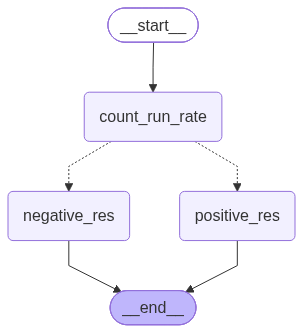

In [100]:
workflow